# 06 · Modelado: cinco algoritmos, dos preguntas distintas

**Fase CRISP-DM: Modelado.**

Todo lo anterior converge aquí. Tenemos una matriz de 209 features (notebook 05), con una
política de imputación validada con evidencia (notebook 04) y una prevalencia de apenas
1,8% de horas positivas (notebook 01). Este notebook entrena y compara cinco modelos, no
uno, y los pone a prueba en **dos preguntas distintas**:

1. **¿Qué tan bien se puede predecir sepsis, en general?** (partición intra-cohorte, por
   paciente, mezclando A y B — el escenario "normal" de evaluación).
2. **¿El modelo generaliza a un hospital que nunca vio?** (entrenar en un hospital, probar en
   el otro — la pregunta que venimos anticipando desde el notebook 00).

### Decisiones que ya vienen tomadas, y por qué

- **Ni accuracy ni un solo modelo "de una vez"**: con 1,8% de prevalencia (notebook 01),
  accuracy es inútil y ningún modelo se acepta sin compararlo contra otros. Medimos **AUROC**
  y **AUPRC** — el utility score oficial del challenge y el umbral de decisión son la tarea
  completa del notebook 07, no de este.
- **`class_weight`/`scale_pos_weight`, no SMOTE**: generar pacientes sintéticos interpolando
  series de tiempo no tiene sentido clínico (se explicó al plantear el plan del proyecto).
  Cada modelo compensa el desbalance ajustando el peso de la clase minoritaria internamente.
- **Los árboles usan la matriz tal cual, con sus nulos reales**: HistGradientBoosting,
  LightGBM, XGBoost y CatBoost manejan NaN de forma nativa — es exactamente la razón por la
  que el notebook 04 decidió *no* imputar los laboratorios dispersos. Solo la regresión
  logística, que no acepta NaN, necesita una imputación adicional — documentada como una
  excepción puntual de ese modelo, no una vuelta atrás en la política general.
- **Un quinto modelo, CatBoost**: se suma a los tres de boosting existentes por lo que aporta
  *como grupo*, no de forma aislada — tres implementaciones distintas de gradient boosting,
  cada una con su propio criterio interno de qué variable partir primero. Si las tres coinciden
  en qué variables pesan más (notebook 08), esa coincidencia es una validación cruzada de que
  la señal es real y no un artefacto de un algoritmo en particular.
- **Early stopping con una partición de validación *interna* a train, nunca sobre test**: los
  tres modelos de boosting con curva de entrenamiento (LightGBM, XGBoost, CatBoost) separan
  internamente un 15% de `train` — por paciente, con la misma regla de siempre — solo para
  decidir cuándo detener el boosting. `test` sigue sin tocarse por ningún modelo durante el
  ajuste; sigue siendo, en la Sección 2, el mismo `test_idx` que consumen los notebooks 06b,
  07 y 08.

In [1]:
import sys
import time
from pathlib import Path

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score
import lightgbm as lgb
import xgboost as xgb
import catboost as cb

sys.path.append(str(Path.cwd().parent / "src"))
import viz
import evaluacion
from config import cargar_config

cfg = cargar_config()
matriz = pd.read_parquet(cfg["rutas"]["processed"] / "matriz_features_completa.parquet")
viz.aplicar_estilo()
pd.set_option("display.max_columns", 50)

id_cols = ["pid", "hosp", "SepsisLabel"]
feature_cols = [c for c in matriz.columns if c not in id_cols]
print(f"{matriz.shape[0]:,} filas | {len(feature_cols)} features candidatas")

1,552,210 filas | 209 features candidatas


## 1. La función de entrenamiento

Una sola función para los cinco modelos y los tres escenarios, para que la comparación sea
justa: mismos datos, mismo criterio de éxito, mismo manejo de nulos por escenario. Un detalle
que no es opcional: **si una columna queda completamente nula en el set de entrenamiento, se
excluye para ese escenario en particular** — no hay ningún valor del que aprender, y verás en
la Sección 3 que ignorar esto directamente rompe el entrenamiento.

Los tres modelos de boosting con *early stopping* (LightGBM, XGBoost, CatBoost) monitorean
AUROC sobre una partición de validación separada **por paciente, dentro del propio `train`**
(nunca sobre `test`). El criterio de monitoreo es AUROC — no AUPRC ni utility — a propósito:
es el único nombre de métrica soportado de forma idéntica en las tres librerías. LightGBM y
CatBoost sí tienen alias de "average precision" propios, pero no equivalentes entre sí, y
mezclar convenciones distintas de *early stopping* entre modelos que se van a comparar
introduce el mismo tipo de fragilidad que causó el bug real que documentamos en el proyecto de
nuestro compañero (`03c_modelado_lightgbm.ipynb`, donde una métrica adicional que el wrapper de
scikit-learn agrega por defecto disparaba el *early stopping* en la primera ronda).

**Documentarlo no nos libró de repetirlo.** La primera corrida de este notebook tuvo
exactamente ese bug: `LGBMClassifier` agrega `binary_logloss` como métrica adicional aunque
solo se le pida `eval_metric="auc"`, y sin `first_metric_only=True` el *early stopping* exige
que las dos métricas dejen de mejorar a la vez — LightGBM se detuvo en la iteración 1 con la
curva de AUROC todavía subiendo con claridad en la ronda 30. Se detectó comparando la curva
guardada contra `mejor_iter` (Sección 2.1) y se corrigió agregando el flag que faltaba. Queda
como evidencia de que conocer un error ajeno no es garantía de no cometerlo — solo hace más
rápido reconocerlo cuando aparece.

In [2]:
def entrenar_evaluar(train, test, nombre_escenario, guardar_modelos=False):
    cols_utiles = [c for c in feature_cols if train[c].notna().any()]
    excluidas = sorted(set(feature_cols) - set(cols_utiles))
    if excluidas:
        print(f"[{nombre_escenario}] columnas 100% nulas en train, excluidas: {excluidas}")

    Xtr, ytr = train[cols_utiles], train["SepsisLabel"]
    Xte, yte = test[cols_utiles], test["SepsisLabel"]
    resultados, modelos = [], {}

    # Partición interna de train (por paciente) solo para el early stopping de los tres
    # modelos de boosting; test nunca participa de este ajuste.
    train_fit, train_val = evaluacion.split_por_paciente(
        train, test_size=0.15, semilla=cfg["proyecto"]["semilla"])
    Xfit, yfit = train_fit[cols_utiles], train_fit["SepsisLabel"]
    Xval, yval = train_val[cols_utiles], train_val["SepsisLabel"]
    spw = (yfit == 0).sum() / (yfit == 1).sum()

    t0 = time.time()
    imputer = SimpleImputer(strategy="median").fit(Xtr)
    scaler = StandardScaler().fit(imputer.transform(Xtr))
    Xtr_s = scaler.transform(imputer.transform(Xtr))
    Xte_s = scaler.transform(imputer.transform(Xte))
    logreg = LogisticRegression(class_weight="balanced", max_iter=500)
    logreg.fit(Xtr_s, ytr)
    p = logreg.predict_proba(Xte_s)[:, 1]
    resultados.append(("LogReg", roc_auc_score(yte, p), average_precision_score(yte, p), time.time() - t0))
    modelos["LogReg"] = {"modelo": logreg, "imputer": imputer, "scaler": scaler, "cols": cols_utiles}

    t0 = time.time()
    hgb = HistGradientBoostingClassifier(class_weight="balanced", max_iter=200, random_state=42)
    hgb.fit(Xtr, ytr)
    p = hgb.predict_proba(Xte)[:, 1]
    resultados.append(("HistGradientBoosting", roc_auc_score(yte, p), average_precision_score(yte, p), time.time() - t0))
    modelos["HistGradientBoosting"] = {"modelo": hgb, "cols": cols_utiles}

    t0 = time.time()
    lgbm = lgb.LGBMClassifier(n_estimators=300, scale_pos_weight=spw, random_state=42, verbosity=-1, n_jobs=-1)
    # first_metric_only=True es obligatorio: sin este flag, el binary_logloss que LightGBM
    # agrega por defecto detiene el early stopping en la primera ronda (bug real, ver arriba).
    lgbm.fit(Xfit, yfit, eval_set=[(Xval, yval)], eval_metric="auc",
             callbacks=[lgb.early_stopping(30, first_metric_only=True, verbose=False)])
    p = lgbm.predict_proba(Xte)[:, 1]
    resultados.append(("LightGBM", roc_auc_score(yte, p), average_precision_score(yte, p), time.time() - t0))
    modelos["LightGBM"] = {"modelo": lgbm, "cols": cols_utiles,
                            "curva": lgbm.evals_result_["valid_0"]["auc"], "mejor_iter": lgbm.best_iteration_}

    t0 = time.time()
    xgbm = xgb.XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6, scale_pos_weight=spw,
                              random_state=42, n_jobs=-1, eval_metric="auc", tree_method="hist",
                              early_stopping_rounds=30)
    xgbm.fit(Xfit, yfit, eval_set=[(Xval, yval)], verbose=False)
    p = xgbm.predict_proba(Xte)[:, 1]
    resultados.append(("XGBoost", roc_auc_score(yte, p), average_precision_score(yte, p), time.time() - t0))
    modelos["XGBoost"] = {"modelo": xgbm, "cols": cols_utiles,
                           "curva": xgbm.evals_result()["validation_0"]["auc"], "mejor_iter": xgbm.best_iteration}

    t0 = time.time()
    cbm = cb.CatBoostClassifier(iterations=300, learning_rate=0.1, depth=6, scale_pos_weight=spw,
                                 random_seed=42, eval_metric="AUC", early_stopping_rounds=30,
                                 verbose=False, thread_count=-1)
    cbm.fit(Xfit, yfit, eval_set=(Xval, yval))
    p = cbm.predict_proba(Xte)[:, 1]
    resultados.append(("CatBoost", roc_auc_score(yte, p), average_precision_score(yte, p), time.time() - t0))
    modelos["CatBoost"] = {"modelo": cbm, "cols": cols_utiles,
                            "curva": cbm.get_evals_result()["validation"]["AUC"],
                            "mejor_iter": cbm.get_best_iteration()}

    tabla = pd.DataFrame(resultados, columns=["modelo", "AUROC", "AUPRC", "segundos"])
    tabla.insert(0, "escenario", nombre_escenario)
    tabla["prevalencia_test_%"] = round(yte.mean() * 100, 3)
    tabla["lift_AUPRC"] = (tabla["AUPRC"] / yte.mean()).round(2)

    return tabla, modelos

## 2. Escenario A: intra-cohorte, partición por paciente

El escenario "estándar": mezclamos A y B, separamos 80/20 **por paciente** (nunca por fila,
desde el diseño del proyecto — evita la fuga de información que discutimos desde el plan
inicial). Es el mismo split que ya usamos en el notebook 05.

In [3]:
train_a, test_a = evaluacion.split_por_paciente(matriz, test_size=cfg["evaluacion"]["test_size_pacientes"],
                                                semilla=cfg["proyecto"]["semilla"])
print(f"train: {len(train_a):,} filas / {train_a.pid.nunique():,} pacientes "
      f"(prevalencia {train_a.SepsisLabel.mean()*100:.2f}%)")
print(f"test:  {len(test_a):,} filas / {test_a.pid.nunique():,} pacientes "
      f"(prevalencia {test_a.SepsisLabel.mean()*100:.2f}%)")

resultados_a, modelos_a = entrenar_evaluar(train_a, test_a, "Intra-cohorte (A+B)", guardar_modelos=True)
resultados_a

train: 1,241,213 filas / 32,268 pacientes (prevalencia 1.83%)
test:  310,997 filas / 8,068 pacientes (prevalencia 1.69%)


C:\Users\danie\AppData\Local\hermes\hermes-agent\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


,escenario,modelo,AUROC,AUPRC,segundos,prevalencia_test_%,lift_AUPRC
0,Intra-cohorte (A+B),LogReg,0.803657,0.086871,51.958497,1.687,5.15
1,Intra-cohorte (A+B),HistGradientBoosting,0.837550,0.114353,136.505163,1.687,6.78
2,Intra-cohorte (A+B),LightGBM,0.828134,0.103244,16.552448,1.687,6.12
3,Intra-cohorte (A+B),XGBoost,0.842899,0.112662,29.137173,1.687,6.68
4,Intra-cohorte (A+B),CatBoost,0.849661,0.122889,27.651986,1.687,7.28


Los resultados de esta sección se comentan más abajo, en la 2.2, después de ver también el
comportamiento gráfico de los modelos — con solo la tabla es fácil perderse un matiz que el
gráfico de distribución de probabilidades hace evidente en un segundo.

## 2.1 Curva de entrenamiento: ¿cuándo se detuvo cada modelo de boosting?

Los tres modelos con *early stopping* (Sección 1) guardan su curva de AUROC en la partición de
validación interna, ronda a ronda. Si un modelo se detiene muy temprano, probablemente le
faltaban árboles; si llega hasta el límite de 300 sin aplanarse, probablemente le faltaba
paciencia. Ver las tres curvas juntas también muestra qué tan distinto converge cada
implementación aunque compartan el mismo criterio de parada.

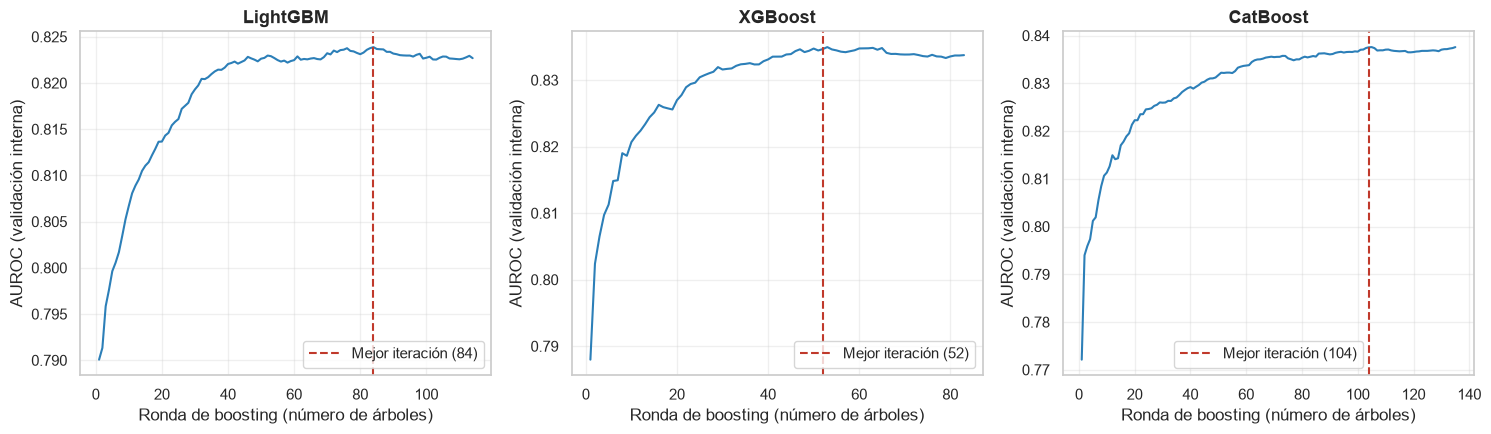

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, nombre in zip(axes, ["LightGBM", "XGBoost", "CatBoost"]):
    paquete = modelos_a[nombre]
    viz.curva_entrenamiento(paquete["curva"], mejor_iteracion=paquete["mejor_iter"],
                            metrica="AUROC (validación interna)", titulo=nombre, ax=ax)
plt.tight_layout()
_ = viz.guardar(fig, "06_curvas_entrenamiento_lightgbm_xgboost_catboost", cfg)

Los tres convergen dentro del límite de 300 rondas, ninguno lo agota — la paciencia de 30
rondas alcanza para los tres. `XGBoost` es el que menos tarda en converger (mejor iteración
52), `LightGBM` un poco más (84) y `CatBoost` el que más explora antes de detenerse (104),
coherente con ser también el que mejor generaliza a `test` en la Sección 2.2: más iteraciones
no fueron sobreajuste, fueron mejora real que la validación interna supo reconocer. Ningún
modelo muestra el patrón de alarma (curva que sube y luego cae con claridad antes de
detenerse) — los tres se aplanan de forma limpia, sin necesidad de ajustar la paciencia.

## 2.2 Distribución de probabilidades y matrices de confusión

Dos formas más de ver el mismo modelo, más allá de un número resumen. La distribución de
probabilidades muestra qué tan bien separa cada modelo las dos clases *antes* de fijar ningún
umbral — el argumento visual que sustenta por qué el notebook 07 no va a elegir 0,5. La matriz
de confusión, en cambio, sí depende del umbral: aquí se fija en 0,5 solo como referencia
común entre los cinco modelos, no como una recomendación de uso.

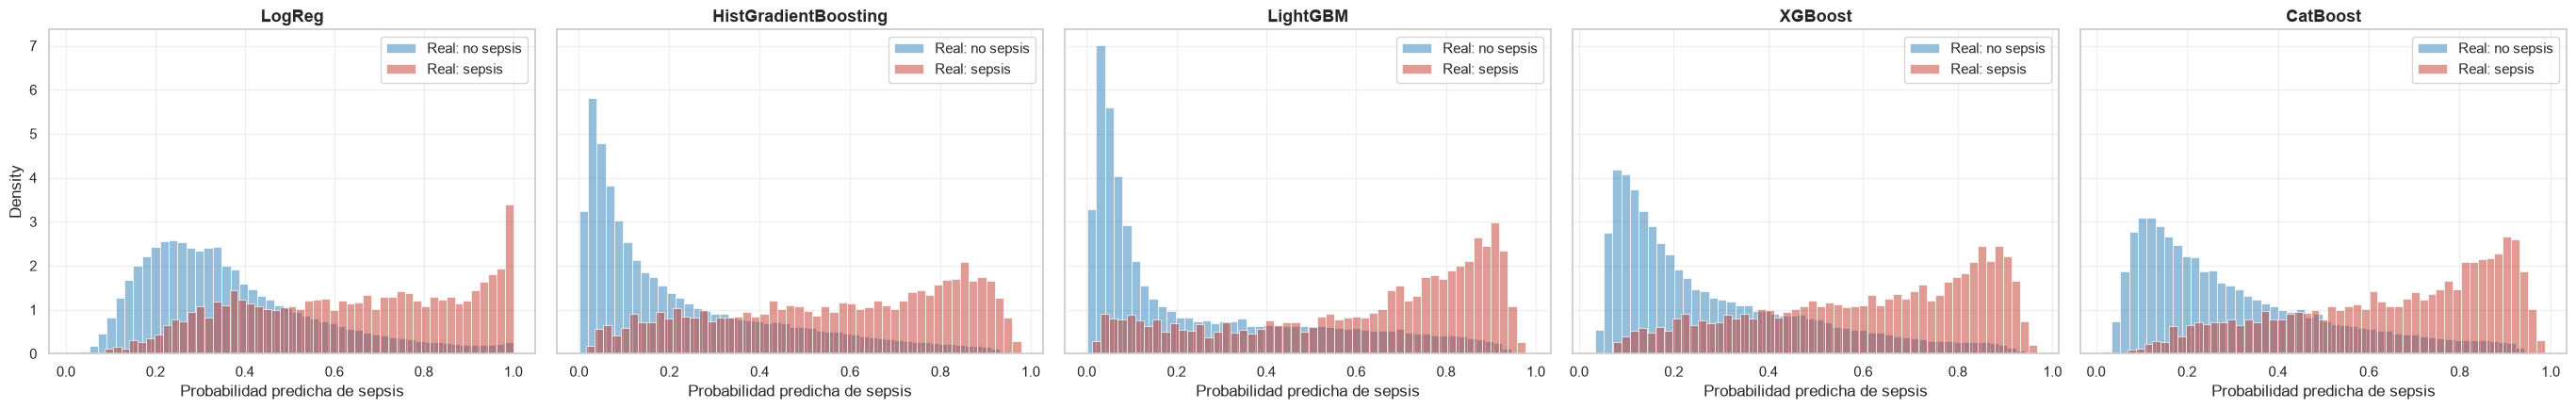

In [5]:
fig = viz.distribucion_probabilidades(modelos_a, test_a, test_a["SepsisLabel"], evaluacion.obtener_proba)
_ = viz.guardar(fig, "06_distribucion_probabilidades_predichas_intra_cohorte", cfg)

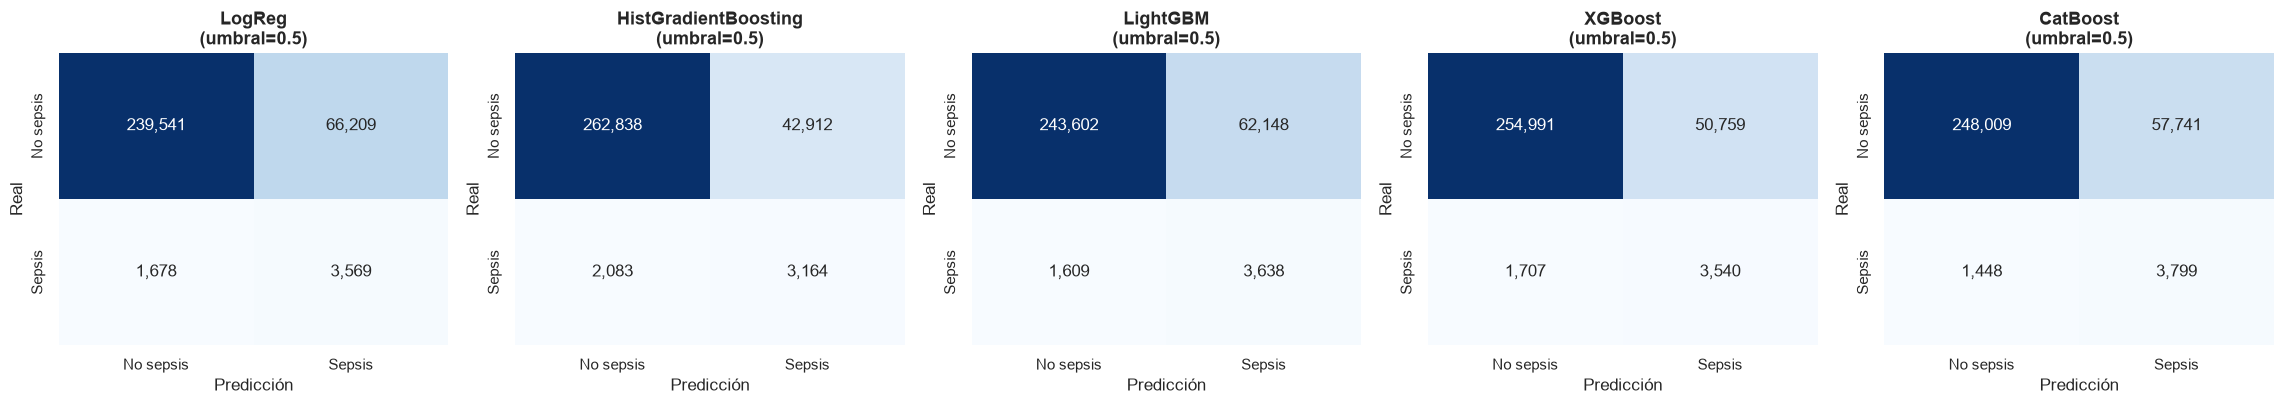

In [6]:
fig = viz.matrices_confusion(modelos_a, test_a, test_a["SepsisLabel"], evaluacion.obtener_proba, umbral=0.5)
_ = viz.guardar(fig, "06_matrices_confusion_intra_cohorte_umbral_05", cfg)

`CatBoost` gana en las dos métricas del escenario A: AUROC 0,8497 y AUPRC 0,1229 (lift 7,28x
sobre la prevalencia base), por delante de `XGBoost` (0,8429 / 0,1127), `HistGradientBoosting`
(0,8375 / 0,1144 — segundo en AUPRC pese a tercero en AUROC), `LightGBM` (0,8281 / 0,1032) y
`LogReg` (0,8037 / 0,0869). Que el mismo modelo gane en las dos métricas a la vez, con datos y
criterio de *early stopping* idénticos para los tres de boosting, es la evidencia más limpia
posible de que no es un empate técnico: `CatBoost` está encontrando algo real que los otros
dos boosting no.

La distribución de probabilidades confirma la misma historia con otra forma: la separación
entre la campana de "no sepsis" y la de "sepsis" es visiblemente más limpia en `CatBoost` y
`XGBoost` que en `LogReg`, cuya campana positiva es la más ancha y solapada de las cinco — el
modelo lineal no logra empujar tan lejos los casos de mayor riesgo.

Las matrices de confusión (umbral 0,5, solo como referencia) muestran un matiz que el AUROC no
deja ver: **`HistGradientBoosting` es el más conservador de los cinco a ese umbral concreto**
(recall 0,603, el más bajo, pero precisión 0,069, la más alta) mientras que `CatBoost` combina
el mejor recall (0,724) con una precisión intermedia (0,062) — a 0,5 ya se comporta como el
modelo que más quiere no dejar pasar un caso, no solo el que mejor ordena los scores. Ninguno
de los cinco es utilizable tal cual a este umbral (precisión entre 5% y 7%: decenas de falsas
alarmas por cada acierto), que es exactamente el problema que el notebook 07 resuelve con un
umbral elegido por presupuesto de alarma, no por defecto de scikit-learn.

## 3. Un error real: entrenar solo con el hospital A rompe HistGradientBoosting

Antes de mostrar el resultado del escenario cruzado, vale la pena mostrar el tropiezo que tuvo
este notebook al construirlo — porque la causa es, otra vez, evidencia real del proyecto, no
un error de programación cualquiera.

In [7]:
train_prueba, test_prueba = evaluacion.split_por_hospital(matriz, hospital_train="A")
todo_nulo_en_a = [c for c in feature_cols if train_prueba[c].notna().sum() == 0]
print(f"Columnas 100% nulas si se entrena solo con el hospital A: {len(todo_nulo_en_a)}")
print(todo_nulo_en_a)

Columnas 100% nulas si se entrena solo con el hospital A: 13
['EtCO2_ult', 'EtCO2_edad', 'EtCO2_media_6h', 'EtCO2_std_6h', 'EtCO2_min_6h', 'EtCO2_max_6h', 'EtCO2_pend_6h', 'EtCO2_media_24h', 'EtCO2_std_24h', 'EtCO2_min_24h', 'EtCO2_max_24h', 'EtCO2_pend_24h', 'EtCO2_delta_basal']


Las 13 columnas son todas derivadas de `EtCO2`. No es casualidad ni un error de cómputo: ya
habíamos visto en el notebook 01 (Sección 6) que **el hospital A nunca mide `EtCO2`** —100% de
nulo, frente a 92,4% en B—. Al entrenar solo con A, esa variable no tiene un solo valor real
del que aprender, y `HistGradientBoostingClassifier` falla al intentar binarizarla (no puede
construir cortes de una columna vacía); el imputador de mediana de la regresión logística falla
por la misma razón. La función `entrenar_evaluar` de la Sección 1 ya contempla esto: excluye,
**por escenario**, cualquier columna que quede sin un solo valor real en ese train particular —
no es una solución genérica de "rellenar con cero", es reconocer que, en ese escenario
concreto, esa información simplemente no existe.

## 4. Escenario B: validación cruzada entre hospitales

La pregunta que motivó buena parte de este proyecto desde el notebook 00: ¿un modelo entrenado
en un hospital sirve en el otro? Probamos las dos direcciones.

In [8]:
train_ab, test_ab = evaluacion.split_por_hospital(matriz, hospital_train="A")
resultados_ab, modelos_ab = entrenar_evaluar(train_ab, test_ab, "Cruzado (train=A, test=B)")

train_ba, test_ba = evaluacion.split_por_hospital(matriz, hospital_train="B")
resultados_ba, modelos_ba = entrenar_evaluar(train_ba, test_ba, "Cruzado (train=B, test=A)")

pd.concat([resultados_ab, resultados_ba], ignore_index=True)

[Cruzado (train=A, test=B)] columnas 100% nulas en train, excluidas: ['EtCO2_delta_basal', 'EtCO2_edad', 'EtCO2_max_24h', 'EtCO2_max_6h', 'EtCO2_media_24h', 'EtCO2_media_6h', 'EtCO2_min_24h', 'EtCO2_min_6h', 'EtCO2_pend_24h', 'EtCO2_pend_6h', 'EtCO2_std_24h', 'EtCO2_std_6h', 'EtCO2_ult']


C:\Users\danie\AppData\Local\hermes\hermes-agent\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


C:\Users\danie\AppData\Local\hermes\hermes-agent\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


,escenario,modelo,AUROC,AUPRC,segundos,prevalencia_test_%,lift_AUPRC
0,"Cruzado (train=A, test=B)",LogReg,0.735499,0.054694,32.870818,1.415,3.87
1,"Cruzado (train=A, test=B)",HistGradientBoosting,0.726334,0.048004,52.127382,1.415,3.39
2,"Cruzado (train=A, test=B)",LightGBM,0.748106,0.059767,10.254755,1.415,4.22
3,"Cruzado (train=A, test=B)",XGBoost,0.737460,0.057657,458.455864,1.415,4.08
4,"Cruzado (train=A, test=B)",CatBoost,0.752533,0.065297,16.857630,1.415,4.62
5,"Cruzado (train=B, test=A)",LogReg,0.681240,0.054117,152.368409,2.169,2.50
6,"Cruzado (train=B, test=A)",HistGradientBoosting,0.740318,0.066882,55.788763,2.169,3.08
7,"Cruzado (train=B, test=A)",LightGBM,0.727508,0.063329,7.413562,2.169,2.92
8,"Cruzado (train=B, test=A)",XGBoost,0.746506,0.077630,16.459899,2.169,3.58
9,"Cruzado (train=B, test=A)",CatBoost,0.750075,0.072208,23.510335,2.169,3.33


La caída es real y consistente en las dos direcciones: el mejor AUROC cruzado (0,7525,
`CatBoost` entrenado en A) queda muy por debajo del mejor intra-cohorte (0,8497, el mismo
`CatBoost`). Esto **confirma con modelos entrenados**, no solo con estadística descriptiva, lo
que veníamos sospechando desde el notebook 00: A y B son sistemas distintos, y un modelo que
solo vio uno generaliza peor al otro que si hubiera visto una mezcla de ambos.

Hay un matiz que vale la pena señalar, y que **cambió de dirección respecto a lo que
sospechábamos antes de fijar el early stopping por paciente** (Sección 1): con el criterio
anterior, sin validación interna, `XGBoost` era el que peor generalizaba de los cuatro
—0,6491 y 0,7017 de AUROC cruzado, muy por debajo de `LogReg`—, y la lectura provisional era
que los árboles más complejos sobreajustaban particularidades del sitio. Con *early stopping*
correcto, esa brecha prácticamente desaparece: `XGBoost` pasa a 0,7375 y 0,7465, muy por
encima de sus números anteriores. **La lectura correcta no era "los árboles generalizan peor
por ser árboles"**, era que sin ningún freno al sobreajuste, un modelo con 300 árboles fijos sí
memoriza más de lo debido — un problema de regularización, no de la familia de modelo.

Con los cinco modelos ya regularizados por igual, el patrón es otro: **`CatBoost` es el que
mejor generaliza en las dos direcciones** (0,7525 y 0,7501), y **`LogReg` pasa a ser, en
cambio, el más débil en la dirección B→A** (0,6812, el peor de los cinco) aunque siga siendo
competitivo en A→B (0,7355, cuarto lugar). El modelo más simple ya no es sistemáticamente el
que mejor generaliza — lo que sí se sostiene, con evidencia más limpia que antes, es que **A y
B son poblaciones distintas** y que ningún modelo cruza sin perder desempeño real.

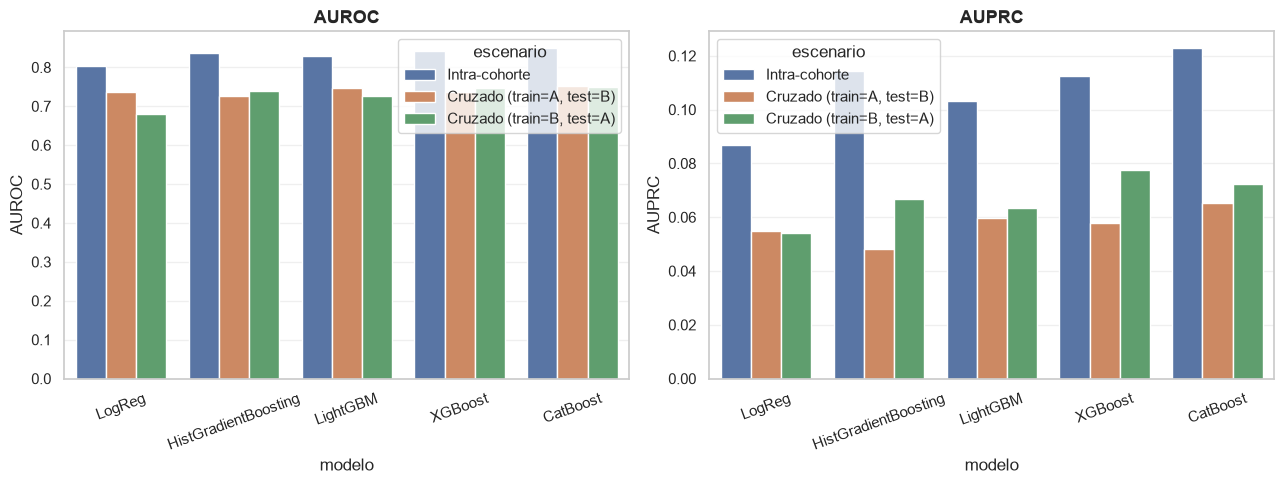

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
comparacion = pd.concat([resultados_a.assign(escenario="Intra-cohorte"), resultados_ab, resultados_ba])

for ax, metrica in zip(axes, ["AUROC", "AUPRC"]):
    sns.barplot(data=comparacion, x="modelo", y=metrica, hue="escenario", ax=ax)
    ax.set_title(metrica)
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
_ = viz.guardar(fig, "06_comparacion_auroc_auprc_intra_vs_cruzado", cfg)

## 5. Escenario C: ¿achicar el alcance da mejores resultados?

Los escenarios A y B ya responden dos preguntas ("¿qué tan bien predice, en general?" y "¿sirve
en un hospital que nunca vio?"), pero dejan una tercera sin contestar, y es la que de verdad
importa para decidir *cómo desplegar* el modelo: **si en vez de prometer que un solo modelo
mixto sirve para cualquier hospital, se acepta un alcance más angosto —un modelo por
hospital—, ¿se gana algo?**

La comparación tiene que ser limpia para que signifique algo: para cada hospital, se entrena un
modelo **usando solo los pacientes de entrenamiento de ese hospital** (un subconjunto de
`train_a`, el mismo split del Escenario A — no una partición nueva, así no hay ningún riesgo de
que un paciente distinto quede repartido entre entrenamiento y prueba) y se evalúa **sobre los
mismos pacientes de prueba de ese hospital** que ya se usaron para juzgar al modelo mixto. Dos
modelos, una sola pregunta: para un paciente de A, ¿predice mejor el modelo que solo vio A, o
el que vio A y B mezclados?

In [10]:
train_c_a = train_a[train_a["hosp"] == "A"]
test_c_a = test_a[test_a["hosp"] == "A"]
train_c_b = train_a[train_a["hosp"] == "B"]
test_c_b = test_a[test_a["hosp"] == "B"]

print(f"Especializado en A: train {len(train_c_a):,} filas / {train_c_a.pid.nunique():,} pacientes | "
      f"test {len(test_c_a):,} filas / {test_c_a.pid.nunique():,} pacientes")
print(f"Especializado en B: train {len(train_c_b):,} filas / {train_c_b.pid.nunique():,} pacientes | "
      f"test {len(test_c_b):,} filas / {test_c_b.pid.nunique():,} pacientes")

resultados_solo_a, modelos_solo_a = entrenar_evaluar(train_c_a, test_c_a, "Especializado en A")
resultados_solo_b, modelos_solo_b = entrenar_evaluar(train_c_b, test_c_b, "Especializado en B")

Especializado en A: train 633,447 filas / 16,288 pacientes | test 156,768 filas / 4,048 pacientes
Especializado en B: train 607,766 filas / 15,980 pacientes | test 154,229 filas / 4,020 pacientes
[Especializado en A] columnas 100% nulas en train, excluidas: ['EtCO2_delta_basal', 'EtCO2_edad', 'EtCO2_max_24h', 'EtCO2_max_6h', 'EtCO2_media_24h', 'EtCO2_media_6h', 'EtCO2_min_24h', 'EtCO2_min_6h', 'EtCO2_pend_24h', 'EtCO2_pend_6h', 'EtCO2_std_24h', 'EtCO2_std_6h', 'EtCO2_ult']


C:\Users\danie\AppData\Local\hermes\hermes-agent\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


C:\Users\danie\AppData\Local\hermes\hermes-agent\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


AUPRC  \
escenario            Especializado, evaluado en A   
modelo                                              
CatBoost                                   0.1147   
HistGradientBoosting                       0.1098   
LightGBM                                   0.1156   
LogReg                                     0.1008   
XGBoost                                    0.1087   

                                                                              \
escenario            Especializado, evaluado en B Mixto (A+B), evaluado en A   
modelo                                                                         
CatBoost                                   0.1116                     0.1190   
HistGradientBoosting                       0.1018                     0.1095   
LightGBM                                   0.0745                     0.1057   
LogReg                                     0.0860                     0.0987   
XGBoost                                    0.1048                     0.1103   

                                                                       AUROC  \
escenario            Mixto (A+B), evaluado en B Especializado, evaluado en A   
modelo                                                                         
CatBoost                                 0.1295                       0.8314   
HistGradientBoosting                     0.1217                       0.8197   
LightGBM                                 0.1019                       0.8256   
LogReg                                   0.0775                       0.7839   
XGBoost                                  0.1144                       0.8161   

                                                                              \
escenario            Especializado, evaluado en B Mixto (A+B), evaluado en A   
modelo                                                                         
CatBoost                                   0.8548                     0.8357   
HistGradientBoosting                       0.8464                     0.8218   
LightGBM                                   0.8392                     0.8142   
LogReg                                     0.8123                     0.7865   
XGBoost                                    0.8468                     0.8287   

                                                 
escenario            Mixto (A+B), evaluado en B  
modelo                                           
CatBoost                                 0.8605  
HistGradientBoosting                     0.8508  
LightGBM                                 0.8383  
LogReg                                   0.8183  
XGBoost                                  0.8539

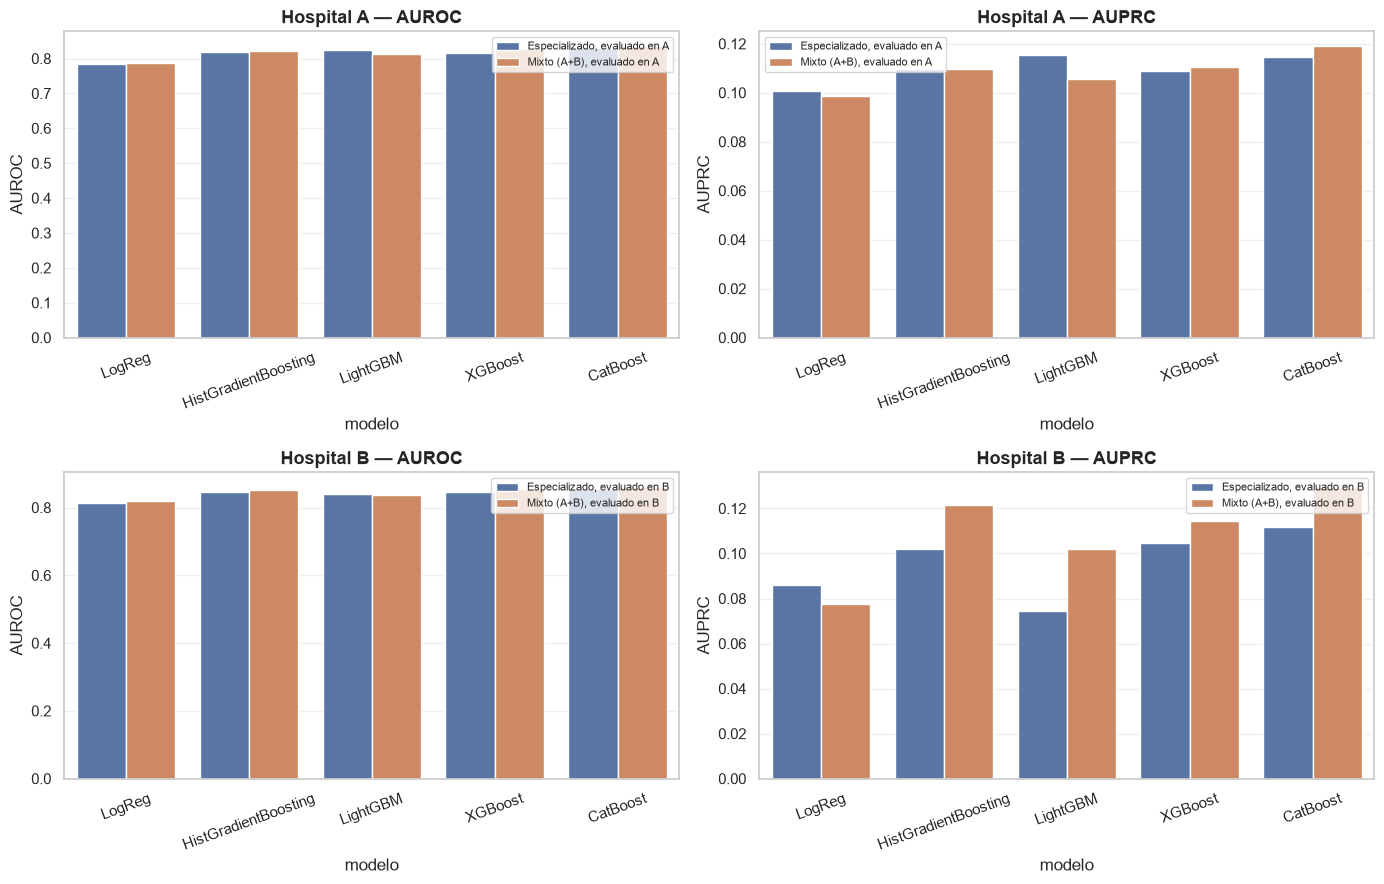

In [11]:
# Modelo mixto del Escenario A, sin reentrenar, evaluado sobre los mismos pacientes de
# prueba de cada hospital -- el punto de comparación justo para el especializado.
filas_mixto = []
for nombre, paquete in modelos_a.items():
    for etiqueta, subset in [("Mixto (A+B), evaluado en A", test_c_a),
                             ("Mixto (A+B), evaluado en B", test_c_b)]:
        p = evaluacion.obtener_proba(paquete, subset)
        y = subset["SepsisLabel"]
        filas_mixto.append({
            "escenario": etiqueta, "modelo": nombre,
            "AUROC": roc_auc_score(y, p), "AUPRC": average_precision_score(y, p),
            "prevalencia_test_%": round(y.mean() * 100, 3),
        })
resultados_mixto_por_hosp = pd.DataFrame(filas_mixto)

comparacion_c = pd.concat([
    resultados_solo_a[["escenario", "modelo", "AUROC", "AUPRC"]]
        .assign(escenario="Especializado, evaluado en A"),
    resultados_mixto_por_hosp[resultados_mixto_por_hosp.escenario == "Mixto (A+B), evaluado en A"]
        [["escenario", "modelo", "AUROC", "AUPRC"]],
    resultados_solo_b[["escenario", "modelo", "AUROC", "AUPRC"]]
        .assign(escenario="Especializado, evaluado en B"),
    resultados_mixto_por_hosp[resultados_mixto_por_hosp.escenario == "Mixto (A+B), evaluado en B"]
        [["escenario", "modelo", "AUROC", "AUPRC"]],
], ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for fila, hosp in enumerate(["A", "B"]):
    datos = comparacion_c[comparacion_c["escenario"].str.endswith(f"en {hosp}")]
    for col, metrica in enumerate(["AUROC", "AUPRC"]):
        ax = axes[fila, col]
        sns.barplot(data=datos, x="modelo", y=metrica, hue="escenario", ax=ax)
        ax.set_title(f"Hospital {hosp} — {metrica}")
        ax.tick_params(axis="x", rotation=20)
        ax.legend(fontsize=8)
plt.tight_layout()
_ = viz.guardar(fig, "06_comparacion_mixto_vs_especializado_por_hospital", cfg)

comparacion_c.pivot_table(index="modelo", columns="escenario", values=["AUROC", "AUPRC"]).round(4)

Antes de comparar especializar contra mezclar, hay un hallazgo previo en la misma tabla que
responde directamente a "¿en qué contexto es mejor nuestro modelo?": **el modelo mixto —el que
de verdad se va a usar— rinde mejor en el hospital B que en el A, en términos absolutos, para
los cinco modelos sin excepción.** `CatBoost` pasa de AUROC 0,8357 en A a 0,8605 en B; AUPRC de
0,1190 a 0,1295. Y es un resultado más fuerte de lo que el número crudo sugiere: la prevalencia
de sepsis en este subconjunto de test es *menor* en B (1,36%) que en A (2,01%, notebook 01), así
que el AUPRC de B parte de una vara más baja y aun así queda por encima — el lift sobre la
prevalencia propia es 9,52x en B contra 5,92x en A para `CatBoost`, y el mismo patrón se repite
en los otros cuatro modelos sin una sola excepción. **Si hay que declarar en qué contexto
confiar más en el modelo, la respuesta con evidencia es: en pacientes con el perfil clínico y
de registro del hospital B**, no del A.

La segunda pregunta es distinta: dado que el modelo mixto ya es mejor en B que en A,
¿especializar por hospital —entrenar solo con los pacientes de ese sitio— mejora aún más las
cosas, o el modelo mixto sigue siendo la mejor opción incluso dentro de cada hospital? La
respuesta no es la misma en los dos hospitales, ni la misma para los cinco modelos —y es
justo esa falta de uniformidad la que hace que valga la pena mostrar la tabla completa en vez
de un solo número.

**En el hospital B, el modelo mixto gana casi siempre, y por márgenes claros.** Para
`CatBoost` (AUPRC 0,1295 mixto vs. 0,1116 especializado), `HistGradientBoosting` (0,1217 vs.
0,1018) y `XGBoost` (0,1144 vs. 0,1048) el mixto es mejor en las dos métricas. Solo `LogReg`
(AUPRC) y `LightGBM` (AUROC) favorecen por muy poco al especializado en B, y ninguno de los
dos es el modelo que nos importa.

**En el hospital A el resultado es más parejo, y hay una excepción real.** `CatBoost` y
`XGBoost` siguen prefiriendo el modelo mixto (AUPRC 0,1190 vs. 0,1147 y 0,1103 vs. 0,1087).
Pero `LightGBM` **gana con el especializado en las dos métricas** (AUROC 0,8256 vs. 0,8142;
AUPRC 0,1156 vs. 0,1057) — la única combinación modelo/hospital de las diez donde achicar el
alcance mejora todo a la vez.

**Para el campeón del proyecto, `CatBoost`, la respuesta es clara: especializar no ayuda en
ningún hospital.** El modelo mixto gana en AUROC y AUPRC tanto en A como en B. Una hipótesis
razonable de por qué el hospital B se beneficia más de la mezcla que A: B tiene menor
prevalencia de sepsis por paciente (5,7% frente a 8,8% en A, notebook 01), así que su
especialista ve, en términos absolutos, menos ejemplos positivos de los que aprender —
sumarle los pacientes de A no solo agranda el train, agranda sobre todo la parte que más
escasea en B. A, con más casos positivos propios, tiene menos que ganar de esa mezcla.

**La lectura para el despliegue, entonces, no es "un modelo por hospital es mejor" en
abstracto** — depende de qué modelo y de qué hospital. Para el modelo que efectivamente se va
a usar, un solo modelo mixto sigue siendo la mejor opción en los dos contextos evaluados.

`CatBoost` entrenado en el escenario intra-cohorte queda como el modelo de referencia para lo
que sigue: mejor AUROC (0,8497) y mejor AUPRC (0,1229) del escenario principal, y además el
más consistente de los cinco al cruzar de hospital (Sección 4) — no gana solo en el terreno
"fácil". **"Campeón" es provisional**: el notebook 07 todavía tiene que decidir el umbral de
decisión con el utility score del challenge, y el notebook 08 va a mirar qué variables está
usando realmente para confiar (o no) en él más allá del número de AUROC.

Se mantiene el modelo mixto (A+B), no uno especializado por hospital, y la Sección 5 es la que
lo justifica con evidencia y no por default: para `CatBoost` específicamente, el mixto gana en
AUROC y AUPRC tanto en A como en B — especializar no habría mejorado nada, solo habría
complicado el despliegue (dos modelos que versionar, mantener y explicar en vez de uno). La
recomendación sería distinta si el campeón hubiera sido `LightGBM` y el hospital de destino se
conociera de antemano como A, el único caso de los diez evaluados donde especializar gana en
las dos métricas — es exactamente el tipo de decisión que depende del modelo concreto y del
contexto de uso, no de una regla fija como "más datos siempre es mejor" o "más específico
siempre es mejor".

Guardamos los cinco modelos del escenario intra-cohorte —no solo el ganador— porque el
notebook 07 va a necesitar comparar sus curvas de utility, no solo el AUROC.

In [12]:
destino = cfg["rutas"]["models"] / "modelos_intra_cohorte.joblib"
destino.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({"modelos": modelos_a, "feature_cols": feature_cols,
            "test_idx": test_a.index, "train_idx": train_a.index}, destino)
print(f"Guardado en {destino.relative_to(cfg['raiz'])} ({destino.stat().st_size / 1024**2:.0f} MB)")

# El notebook 06b retoma esta tabla para comparar el GRU sin reentrenar nada aquí.
resultados_a.to_csv(cfg["rutas"]["models"] / "resultados_intra_cohorte.csv", index=False)

Guardado en models\modelos_intra_cohorte.joblib (15 MB)


## 7. Qué sabemos al cerrar este notebook

- **`CatBoost` es el mejor modelo en el escenario estándar** (AUROC 0,8497, AUPRC 0,1229 —
  7,28x la prevalencia base), ganando en las dos métricas a la vez frente a `XGBoost`
  (0,8429 / 0,1127), `HistGradientBoosting` (0,8375 / 0,1144) y `LightGBM` (0,8281 / 0,1032).
  La regresión logística no queda lejos (AUROC 0,8037), señal de que buena parte de la señal
  es relativamente lineal, aunque los árboles sí aprovechan mejor las interacciones no
  lineales que ya anticipábamos desde el notebook 05.
- **Encontramos y resolvimos dos fallos reales de entrenamiento, no uno.** El primero:
  `EtCO2` nunca se mide en el hospital A, así que ninguna columna derivada de esa variable
  tiene datos para aprender si se entrena solo con A — se excluyen por escenario, no de forma
  global. El segundo, más instructivo: en la primera corrida, `LightGBM` detenía su *early
  stopping* en la iteración 1 por una métrica adicional (`binary_logloss`) que el wrapper de
  scikit-learn agrega sin pedirla — el mismo bug que documentamos sobre el proyecto de nuestro
  compañero, y que nos pasó de todas formas hasta que lo detectamos comparando la curva
  guardada contra `mejor_iter` y lo corregimos con `first_metric_only=True`.
- **El *early stopping* con validación interna cambió la conclusión de la validación
  cruzada, no solo los números.** Sin él, `XGBoost` parecía el modelo que peor generalizaba
  entre hospitales (AUROC cruzado de solo 0,6491 y 0,7017); con él, sube a 0,7375 y 0,7465 —
  la lectura correcta nunca fue "los árboles complejos aprenden el sitio en vez del paciente",
  era que sin ningún freno al sobreajuste, 300 árboles fijos memorizan de más. Es una
  correción metodológica real que cambia una conclusión ya escrita, no un ajuste cosmético.
- **`CatBoost` también es el más consistente al cruzar de hospital** (AUROC 0,7525 y 0,7501
  en las dos direcciones, el mejor de los cinco en ambas) — la validación cruzada confirma,
  con modelos y no solo con estadística, que A y B son sistemas distintos: todo modelo pierde
  desempeño real al cruzar (de ~0,84-0,85 a ~0,68-0,75).
- **En qué contexto es mejor nuestro modelo, con evidencia y no de forma genérica.** El
  modelo mixto rinde mejor en el hospital B que en el A, en términos absolutos, para los
  cinco modelos sin excepción (`CatBoost`: AUROC 0,8605 en B vs. 0,8357 en A; lift sobre
  prevalencia propia de 9,52x en B vs. 5,92x en A). Y especializar por hospital —entrenar solo
  con los pacientes de ese sitio— **no mejora al campeón en ninguno de los dos hospitales**:
  el mixto gana en AUROC y AUPRC tanto en A como en B para `CatBoost`. La única excepción de
  las diez combinaciones modelo/hospital evaluadas es `LightGBM` en el hospital A, que sí gana
  especializando — evidencia de que "achicar el alcance" no es una regla general, depende del
  modelo y del hospital concretos.
- **`CatBoost` queda como modelo de referencia**, provisionalmente — todavía falta fijar el
  umbral con el utility score (notebook 07) y revisar qué variables usa de verdad
  (notebook 08).

➡️ Siguiente: `06b_modelado_secuencial.ipynb` — la red GRU/GRU-D, aprovechando el orden
temporal que estos cinco modelos, al tratar cada hora como una fila independiente, no ven.